In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/statlog-german-credit-data/german.data-numeric
/kaggle/input/statlog-german-credit-data/german.data


# German Credit Data - Andrei Goncharenok, Alberto Tirapelle
## Chapters
- Dataset description and exploration
- Plots
- Different classification methods
- Feature importance
- Backward elimination

# Dataset description

The german_data dataset has 21 attributes, with 7 numerical and 14 categorical variables. Each entry represents a person who has taken a loan and is classified as either a good or bad credit risk.

Our goal is to use classification methods to predict credit risk accurately. We will identify the most important features and test different algorithms to find the best approach. This will help banks assess the creditworthiness of borrowers more effectively.

In [4]:
german_data = pd.read_csv('/kaggle/input/statlog-german-credit-data/german.data',sep=' ',  header=None)

# Number of Attributes german: 21 (7 numerical, 14 categorical)

In [5]:
print("Shape of the dataset:")
german_data.shape

Shape of the dataset:


(1000, 21)

In [6]:
print("First few rows of the data:")
german_data.head()

First few rows of the data:


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Make the dataset more comprehensible and interpretable

In [7]:
# We give the correct names to the columns
column_names = [
    'Checking Account Status', 'Duration in Months', 'Credit History', 'Purpose',
    'Credit Amount', 'Savings Account/Bonds', 'Employment Status', 'Installment Rate',
    'Personal Status and Sex', 'Other Debtors/Guarantors', 'Present Residence Since',
    'Property', 'Age in Years', 'Other Installment Plans', 'Housing',
    'Number of Existing Credits at This Bank', 'Job', 'Number of People Liable for Maintenance',
    'Telephone', 'Foreign Worker', 'Target'  # 'Target' is whether the credit is 'Good' or 'Bad'
]
german_data.columns = column_names

In [8]:
# Define the mappings for categorical columns
checking_account_status = {
    'A14': "no checking account", 'A11': "<0 DM", 'A12': "0 <= <200 DM", 'A13': ">= 200 DM"
}
german_data["Checking Account Status"] = german_data["Checking Account Status"].map(checking_account_status)

credit_history = {
    "A34": "critical account", "A33": "delay in paying off", "A32": "existing credits paid back duly till now", 
    "A31": "all credits at this bank paid back duly", "A30": "no credits taken"
}
german_data["Credit History"] = german_data["Credit History"].map(credit_history)

purpose = {
    "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment", "A43": "radio/television", 
    "A44": "domestic appliances", "A45": "repairs", "A46": "education", 'A47': 'vacation', 'A48': 'retraining', 
    'A49': 'business', 'A410': 'others'
}
german_data["Purpose"] = german_data["Purpose"].map(purpose)

savings_account = {
    "A65": "no savings account", "A61": "<100 DM", "A62": "100 <= <500 DM", "A63": "500 <= <1000 DM", 
    "A64": ">=1000 DM"
}
german_data["Savings Account/Bonds"] = german_data["Savings Account/Bonds"].map(savings_account)

employment_status = {
    'A75': ">=7 years", 'A74': "4<= <7 years", 'A73': "1<= <4 years", 'A72': "<1 year", 'A71': "unemployed"
}
german_data["Employment Status"] = german_data["Employment Status"].map(employment_status)

personal_status_sex = {
    'A95': "female:single", 'A94': "male:married/widowed", 'A93': "male:single", 'A92': "female:divorced/separated/married", 
    'A91': "male:divorced/separated"
}
german_data["Personal Status and Sex"] = german_data["Personal Status and Sex"].map(personal_status_sex)

other_debtors_guarantors = {
    'A101': "none", 'A102': "co-applicant", 'A103': "guarantor"
}
german_data["Other Debtors/Guarantors"] = german_data["Other Debtors/Guarantors"].map(other_debtors_guarantors)

property_type = {
    'A121': "real estate", 'A122': "savings agreement/life insurance", 'A123': "car or other", 'A124': "unknown/no property"
}
german_data["Property"] = german_data["Property"].map(property_type)

other_installment_plans = {
    'A143': "none", 'A142': "store", 'A141': "bank"
}
german_data["Other Installment Plans"] = german_data["Other Installment Plans"].map(other_installment_plans)

housing_type = {
    'A153': "for free", 'A152': "own", 'A151': "rent"
}
german_data["Housing"] = german_data["Housing"].map(housing_type)

job_type = {
    'A174': "management/highly qualified employee", 'A173': "skilled employee/official", 'A172': "unskilled - resident", 
    'A171': "unemployed/unskilled - non-resident"
}
german_data["Job"] = german_data["Job"].map(job_type)

telephone_status = {
    'A192': "yes", 'A191': "none"
}
german_data["Telephone"] = german_data["Telephone"].map(telephone_status)

foreign_worker_status = {
    'A201': "yes", 'A202': "no"
}
german_data["Foreign Worker"] = german_data["Foreign Worker"].map(foreign_worker_status)

risk = {
    1: "Good Risk", 2: "Bad Risk"
}
german_data["Target"] = german_data["Target"].map(risk)


In [9]:
# Display the first five rows of the data
print("First five rows of the dataset:")
german_data.head()

First five rows of the dataset:


,Checking Account Status,Duration in Months,Credit History,Purpose,Credit Amount,Savings Account/Bonds,Employment Status,Installment Rate,Personal Status and Sex,Other Debtors/Guarantors,...,Property,Age in Years,Other Installment Plans,Housing,Number of Existing Credits at This Bank,Job,Number of People Liable for Maintenance,Telephone,Foreign Worker,Target
0,<0 DM,6,critical account,radio/television,1169,no savings account,>=7 years,4,male:single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,Good Risk
1,0 <= <200 DM,48,existing credits paid back duly till now,radio/television,5951,<100 DM,1<= <4 years,2,female:divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,Bad Risk
2,no checking account,12,critical account,education,2096,<100 DM,4<= <7 years,2,male:single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,Good Risk
3,<0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,<100 DM,4<= <7 years,2,male:single,guarantor,...,savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,Good Risk
4,<0 DM,24,delay in paying off,car (new),4870,<100 DM,1<= <4 years,3,male:single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,Bad Risk


## Dataset exploration
The dataset contains 1000 rows and 21 columns. We notice there are no missing values in our dataset.

First, we will examine the basic information of the dataset to understand its structure and data types. Next, we will check for any missing values in each column. We will also review the statistical summary of the numerical variables to get an overview of the data distribution. Finally, we will look at the class distribution of the target variable to understand the balance between good and bad credit risks.


In [10]:
print("Info of the dataset:")
german_data.info()

Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Checking Account Status                  1000 non-null   object
 1   Duration in Months                       1000 non-null   int64 
 2   Credit History                           1000 non-null   object
 3   Purpose                                  1000 non-null   object
 4   Credit Amount                            1000 non-null   int64 
 5   Savings Account/Bonds                    1000 non-null   object
 6   Employment Status                        1000 non-null   object
 7   Installment Rate                         1000 non-null   int64 
 8   Personal Status and Sex                  1000 non-null   object
 9   Other Debtors/Guarantors                 1000 non-null   object
 10  Present Residence Since                 

In [11]:
print("Missing values in each column:")
german_data.isnull().sum()

Missing values in each column:


Checking Account Status                    0
Duration in Months                         0
Credit History                             0
Purpose                                    0
Credit Amount                              0
Savings Account/Bonds                      0
Employment Status                          0
Installment Rate                           0
Personal Status and Sex                    0
Other Debtors/Guarantors                   0
Present Residence Since                    0
Property                                   0
Age in Years                               0
Other Installment Plans                    0
Housing                                    0
Number of Existing Credits at This Bank    0
Job                                        0
Number of People Liable for Maintenance    0
Telephone                                  0
Foreign Worker                             0
Target                                     0
dtype: int64

In [12]:
print("Statistical summary:")
german_data.describe()

Statistical summary:


,Duration in Months,Credit Amount,Installment Rate,Present Residence Since,Age in Years,Number of Existing Credits at This Bank,Number of People Liable for Maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [13]:
print("Class distribution in the target variable:")
german_data["Target"].value_counts(normalize=True)

Class distribution in the target variable:


Target
Good Risk    0.7
Bad Risk     0.3
Name: proportion, dtype: float64

# Plots
- Histograms for numerical features
- Count plots for categorical features
- Box plots for numerical features
- Heatmap for numerical features

In [14]:
# Set style and figure size for better visualization
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Suppress specific FutureWarnings (for plotting)
warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')

<Figure size 1500x1000 with 0 Axes>

In [15]:
# There are 7 numerical and 14 categorical (Target is categorical for the moment)

# List of numerical features
numerical_features = ['Credit Amount', 'Duration in Months', 'Age in Years', 'Installment Rate',
                      'Present Residence Since', 'Number of Existing Credits at This Bank',
                      'Number of People Liable for Maintenance']

# List of categorical features
categorical_features = [
    'Checking Account Status', 'Credit History', 'Purpose', 'Savings Account/Bonds', 
    'Employment Status', 'Personal Status and Sex', 'Other Debtors/Guarantors', 
    'Property', 'Other Installment Plans', 'Housing', 'Job', 'Telephone', 
    'Foreign Worker' ] # we don't include Target here

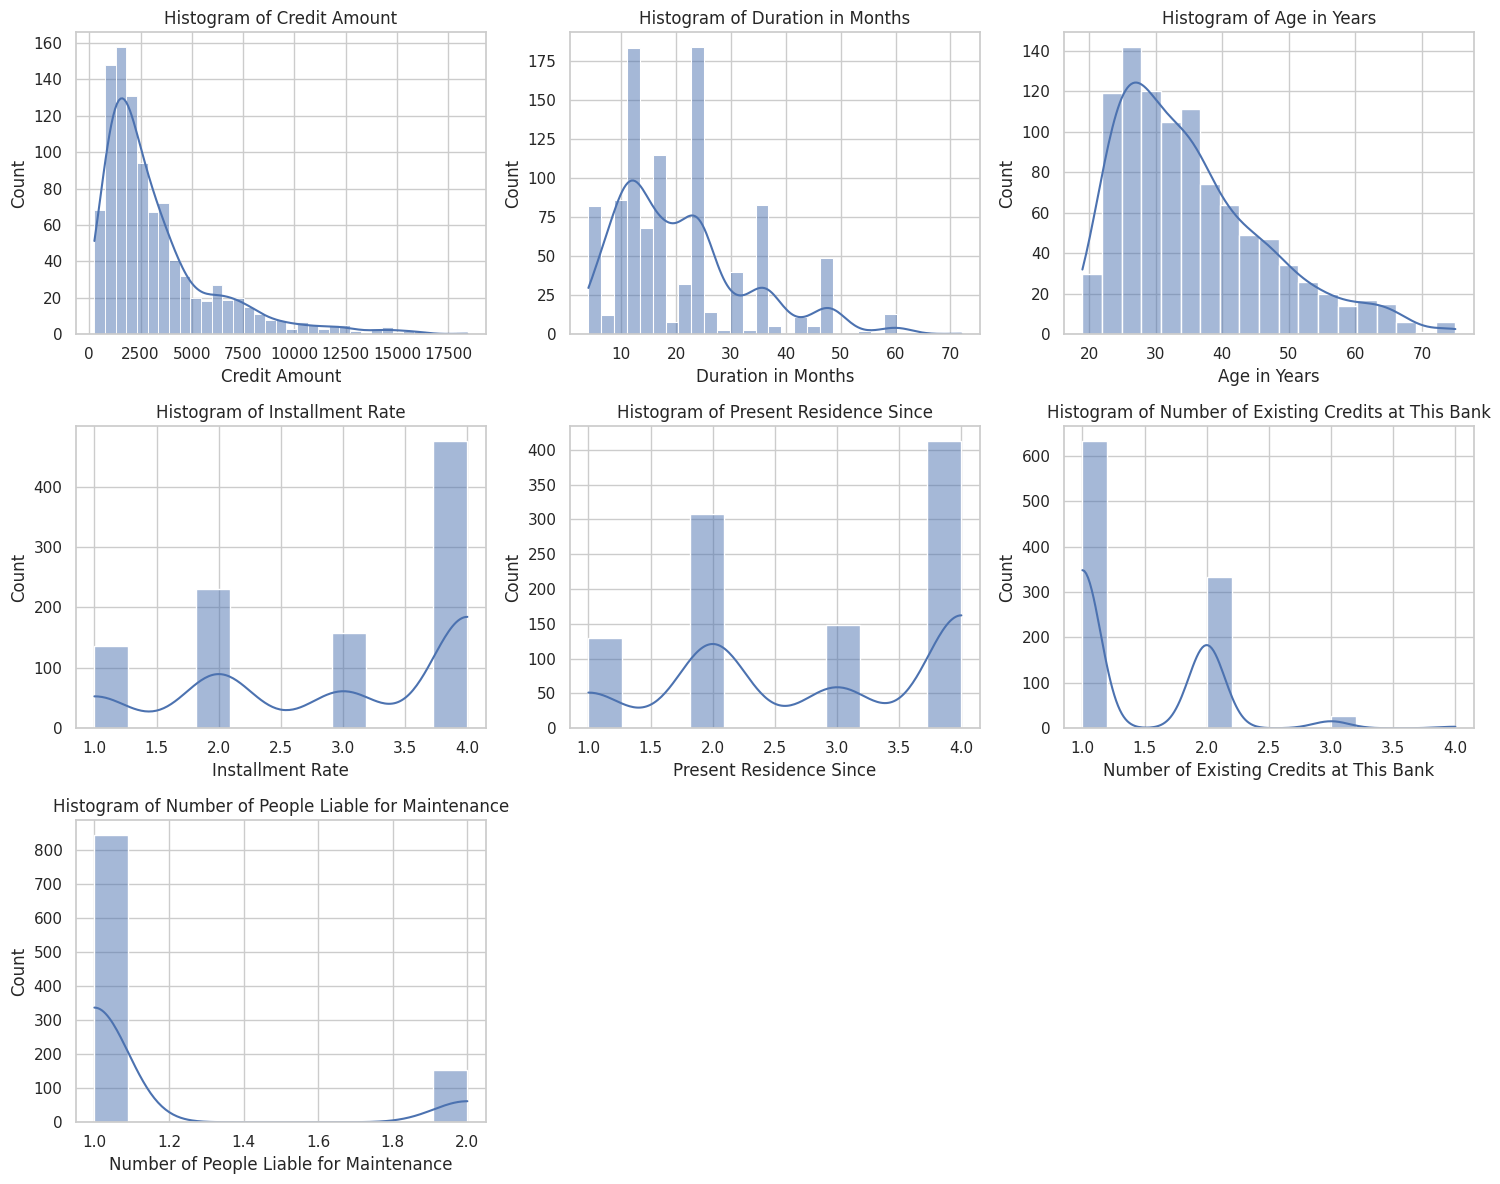

In [16]:
# Histograms for numerical features
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, start=1):
    plt.subplot(3, 3, i)
    sns.histplot(german_data[feature], kde=True)
    plt.title(f"Histogram of {feature}")
plt.tight_layout()
plt.show()

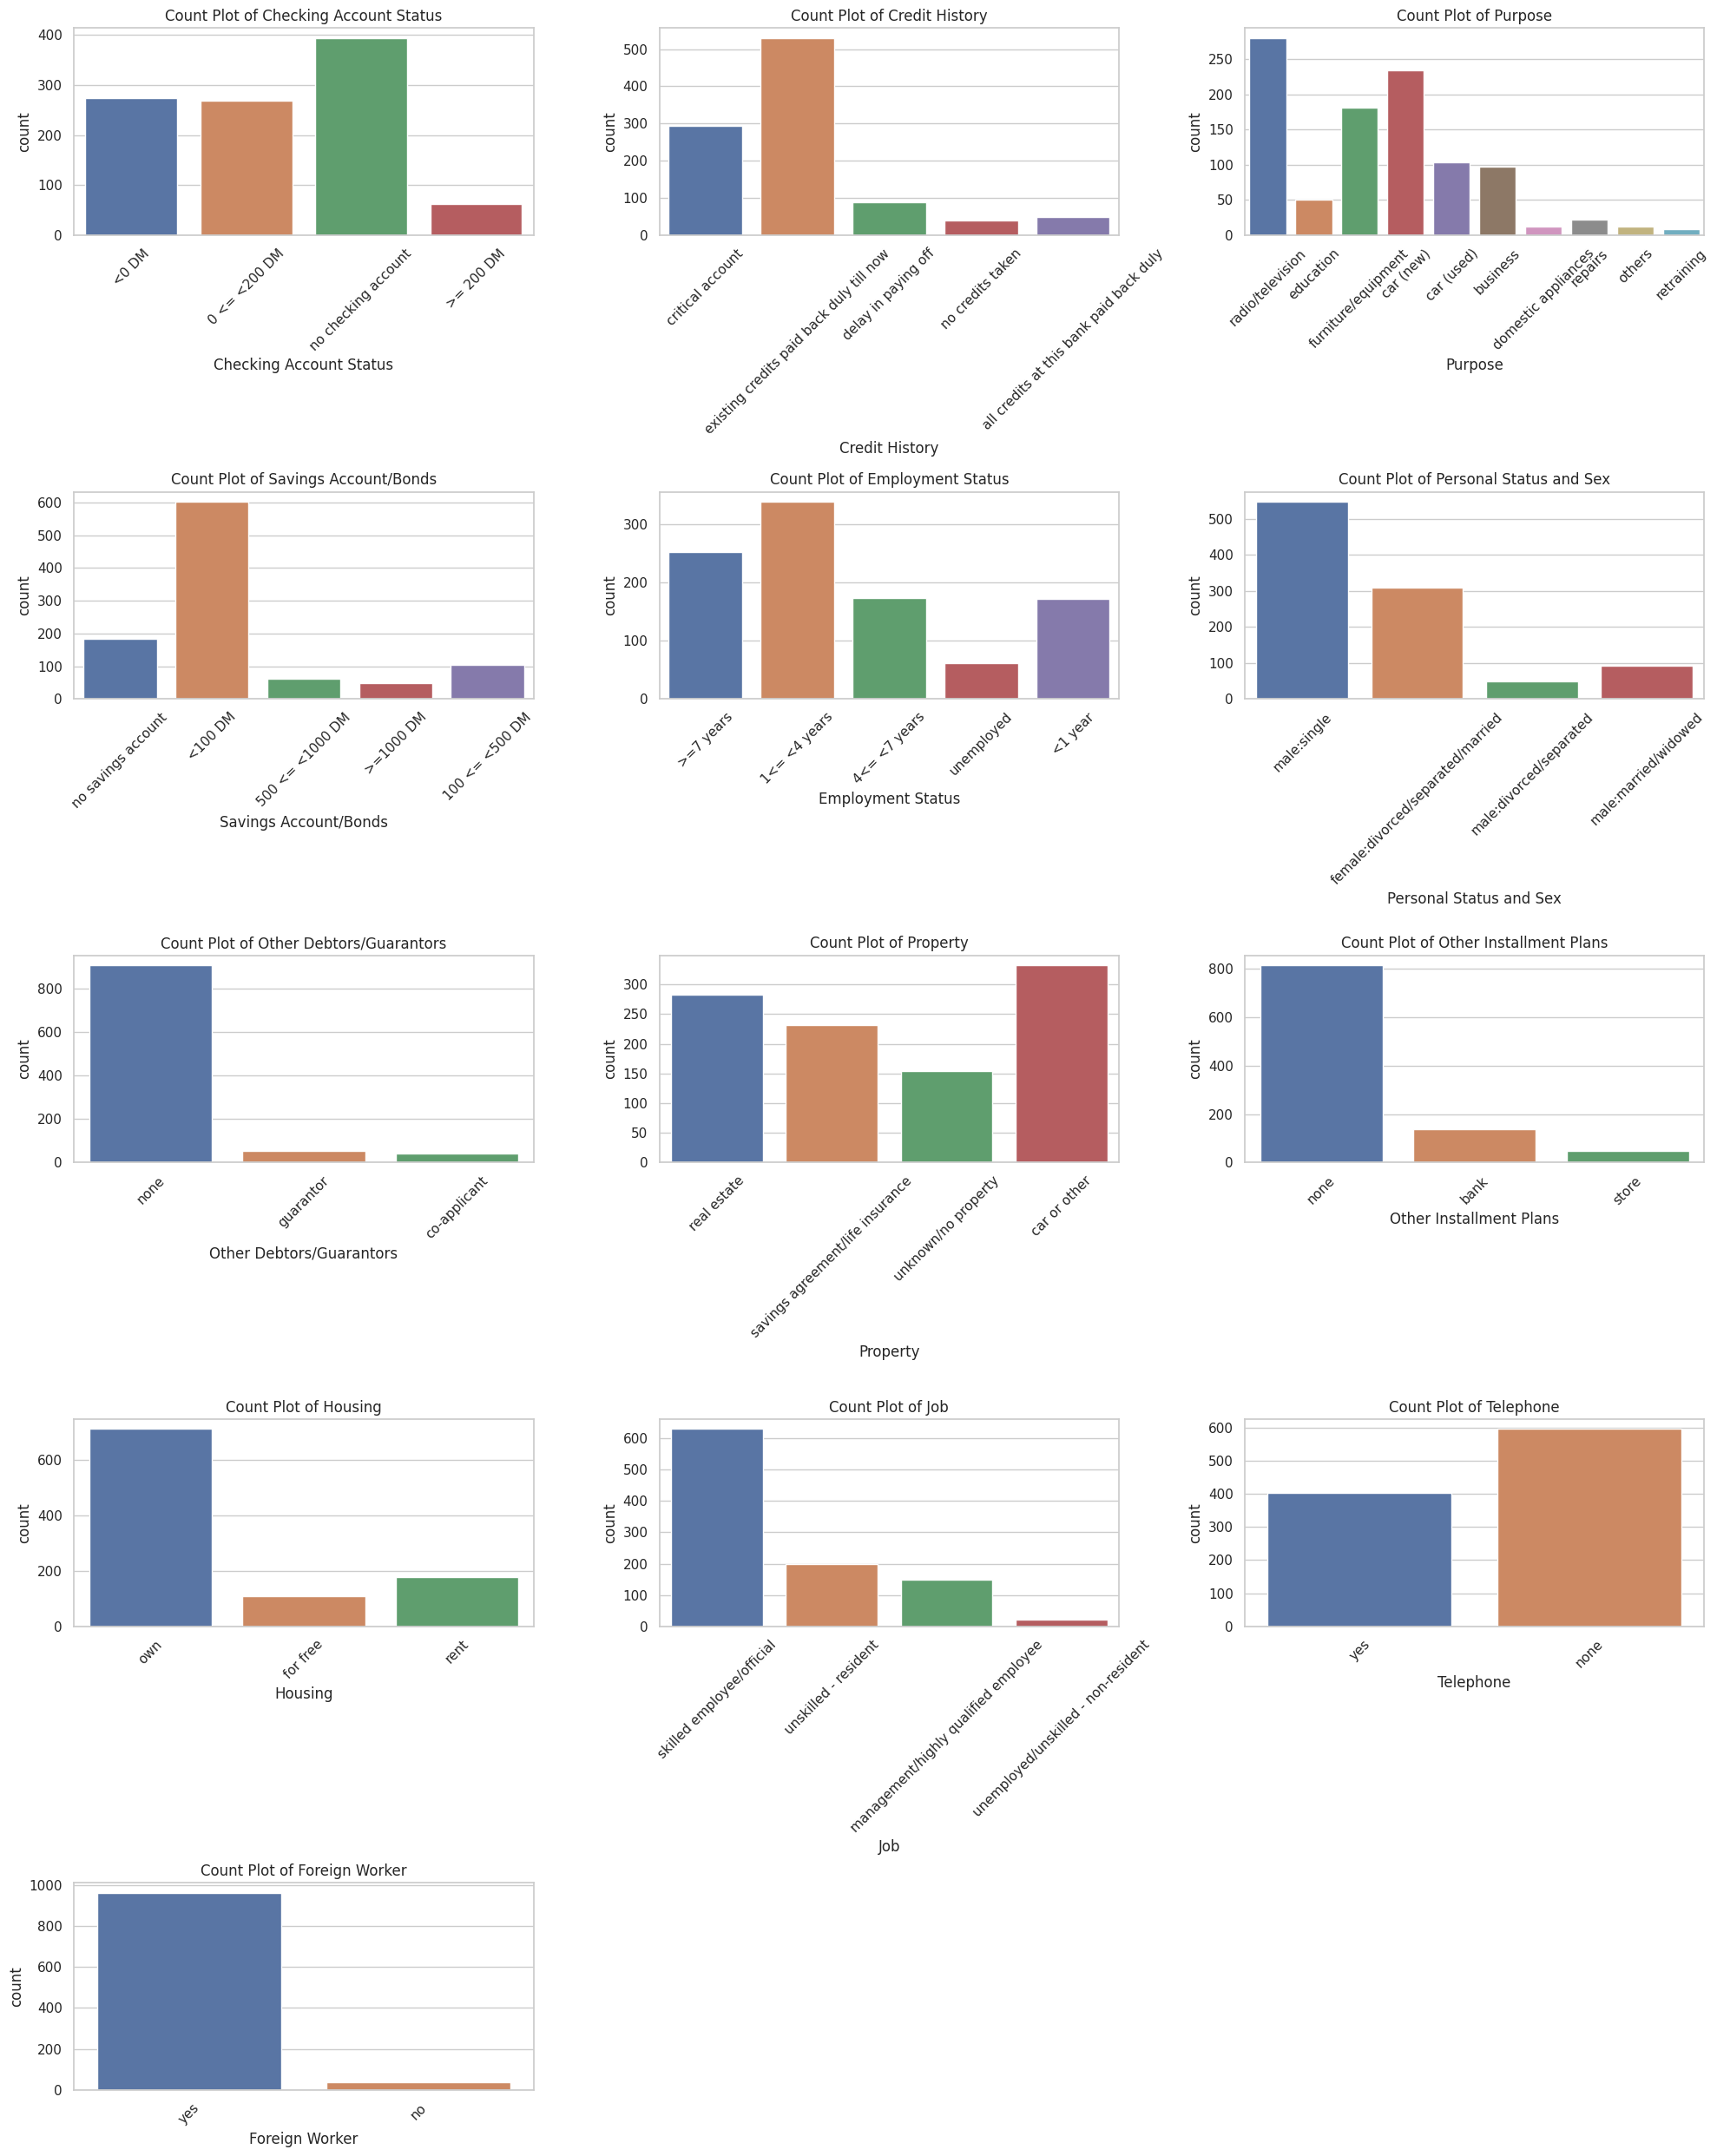

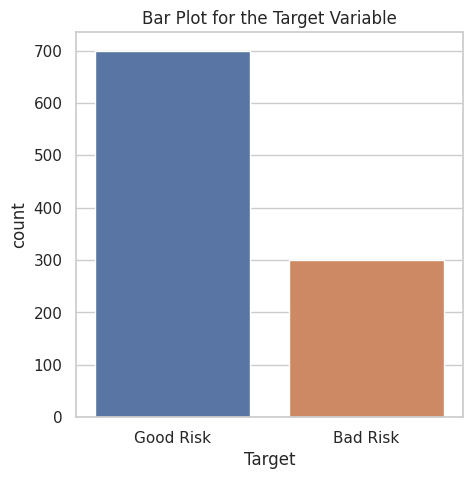

In [17]:
# Count plots for categorical features
plt.figure(figsize=(20, 25))
for i, feature in enumerate(categorical_features, start=1):
    plt.subplot(5, 3, i)
    sns.countplot(x=feature, data=german_data)
    plt.title(f"Count Plot of {feature}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count plot for the target
plt.figure(figsize=(5, 5))
sns.countplot(x='Target', data=german_data)
plt.title("Bar Plot for the Target Variable")
plt.show()

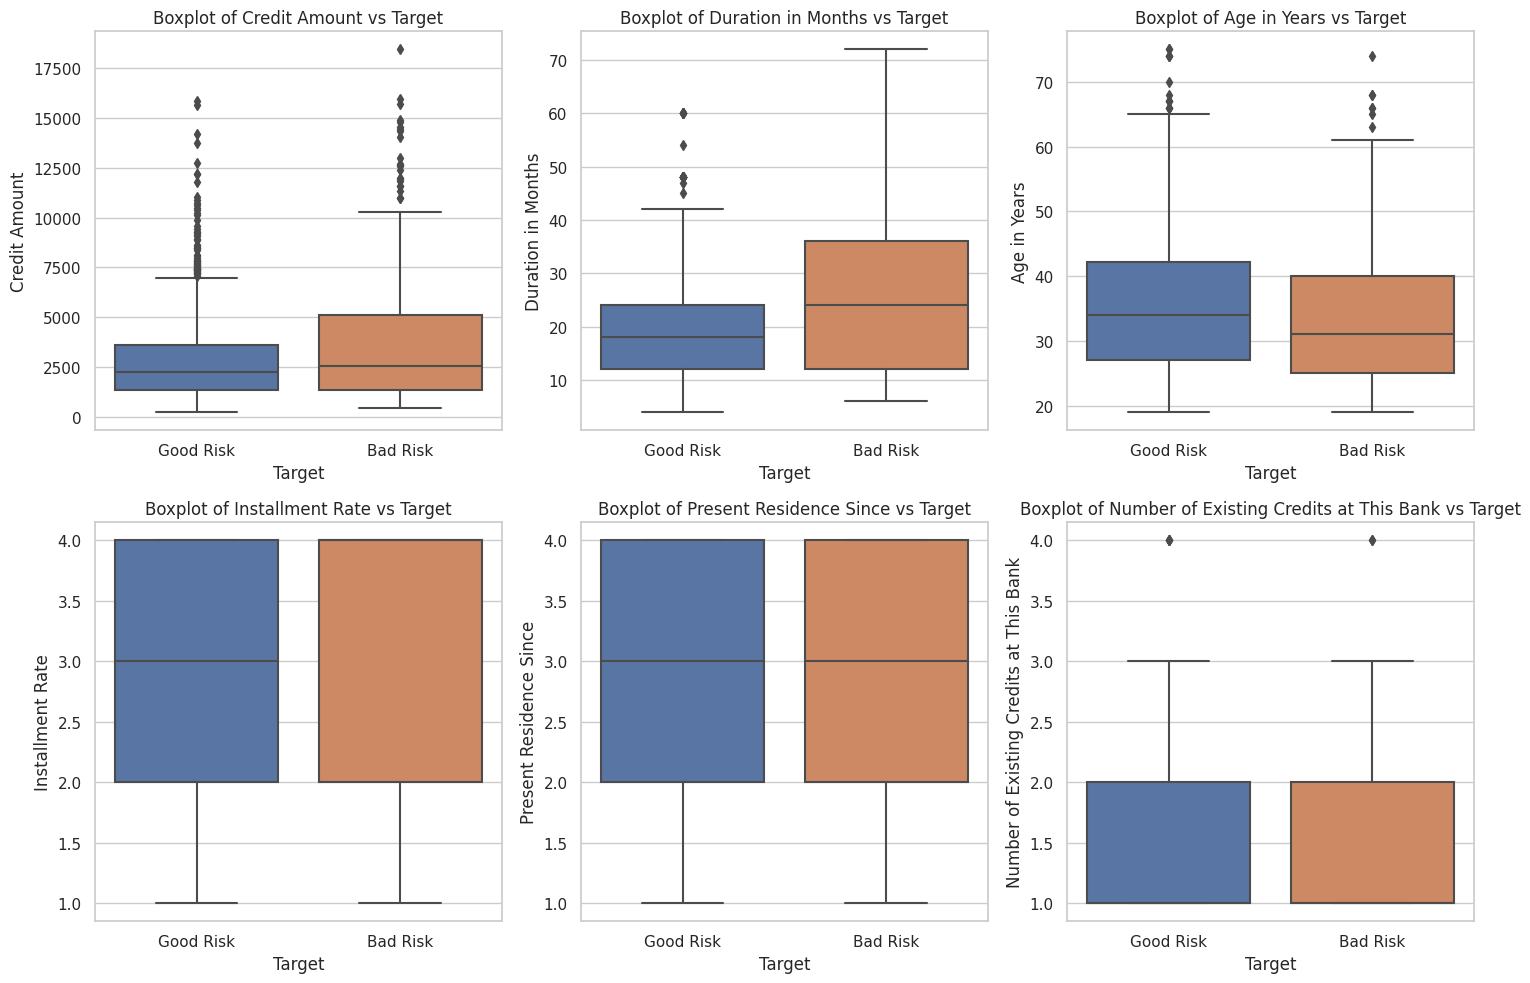

In [18]:
# Boxplot for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features[:-1], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=german_data, x='Target', y=feature)
    plt.title(f'Boxplot of {feature} vs Target')
plt.tight_layout()
plt.show()

In [19]:
# the target was Good Risk and Bad risk
# we map "Good Risk" to 0 and "Bad Risk" to 1

print(german_data["Target"])
mapping = {'Good Risk': 0, 'Bad Risk': 1}
german_data["Target"] = german_data["Target"].map(mapping)
print("")
print(german_data["Target"])

0      Good Risk
1       Bad Risk
2      Good Risk
3      Good Risk
4       Bad Risk
         ...    
995    Good Risk
996    Good Risk
997    Good Risk
998     Bad Risk
999    Good Risk
Name: Target, Length: 1000, dtype: object

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Target, Length: 1000, dtype: int64


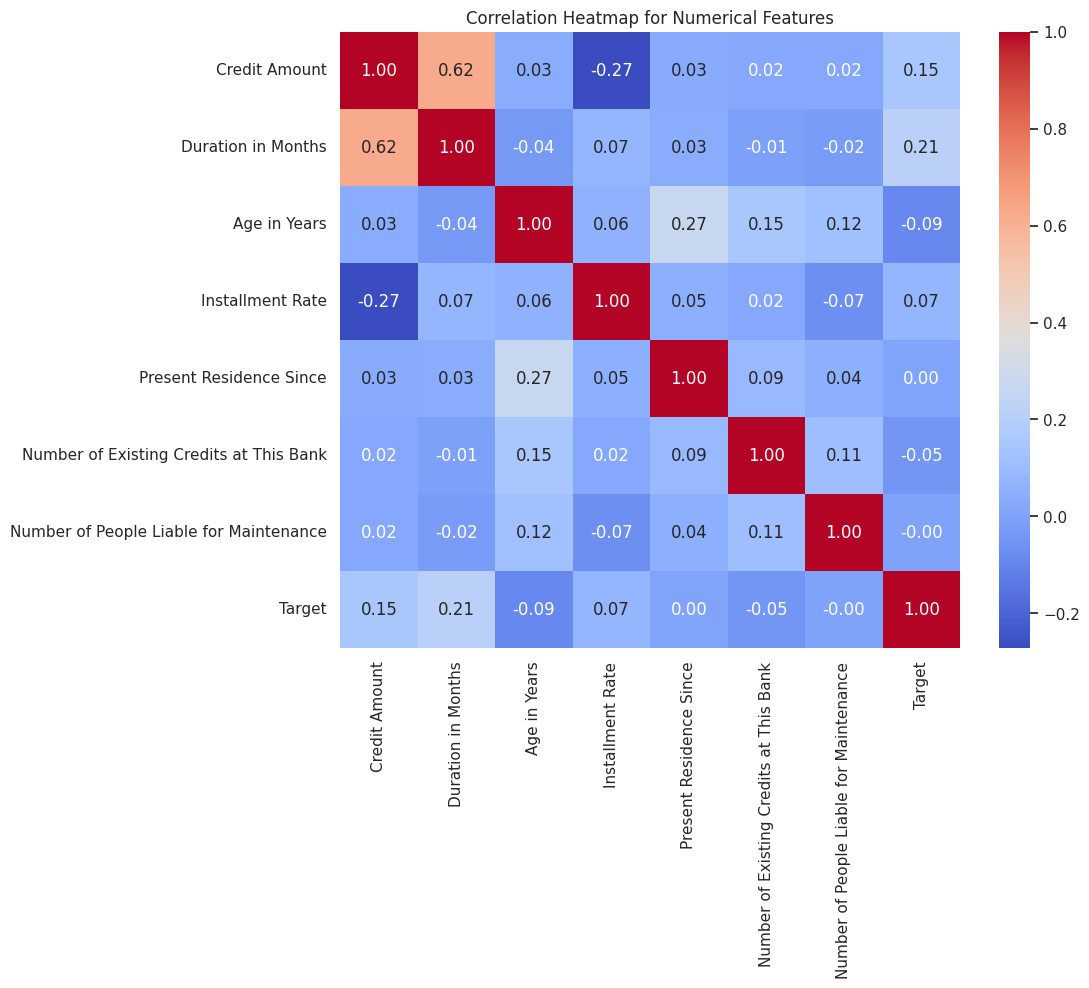

In [20]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(german_data[numerical_features + ['Target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

# Prepare the dataset for the models

We process the dataset, which contains both numerical and categorical features, in such a way that it contains only numerical features.

In this way we will be able to use classification methods.

It is important to perform this after the splitting to avoid data leakage.

In addition, we standanrdize the values.

In [21]:
# Separate features and target variable
X = german_data.drop(columns=['Target'])
y = german_data['Target'] # is already numerical 0,1

In [22]:
# Function to preprocess data
def preprocess_data(X, y, numerical_features, categorical_features):
    # Preprocess numerical features
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')), # fills in missing values
        ('scaler', StandardScaler())                 # standardizes numerical features
    ])

    # Preprocess categorical features
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')), # fills in missing values
        ('onehot', OneHotEncoder(handle_unknown='ignore'))    # converts categorical features into a numerical format
    ])

    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features) 
        ])

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Apply preprocessing
    X_train_processed = preprocessor.fit_transform(X_train)
    # fit_transform is used on the training data (X_train) to calculate statistics like mean, 
    # variance for scaling, and to determine the categories for one-hot encoding. 
    # This fits the preprocessor on the training data and then transforms the training data accordingly
    # When you fit the preprocessor on X_train, it learns the parameters 
    # (e.g., mean and standard deviation for scaling, 
    # categories for one-hot encoding) from the training data
    
    X_test_processed = preprocessor.transform(X_test)
    # transform is used on the testing data (X_test) to apply 
    # the same transformations using the parameters calculated from the training data. 
    # This ensures that the preprocessing is consistent across both the training and testing datasets
    # When you apply transform on X_test, it uses the already learned parameters to ensure 
    # the transformation is consistent with the training data

    # Get feature names after preprocessing
    all_feature_names = preprocessor.transformers_[0][1].named_steps['scaler'].get_feature_names_out(numerical_features).tolist() + \
                        preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
    
    return X_train_processed, X_test_processed, y_train, y_test, all_feature_names

In [23]:
X_train_processed, X_test_processed, y_train, y_test, all_feature_names = preprocess_data(X, y, numerical_features, categorical_features)

In [24]:
# Convert the processed training data to a DataFrame
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

# Display the one-hot encoded DataFrame
print("One-Hot Encoded DataFrame:")
X_train_processed_df.head()

One-Hot Encoded DataFrame:


,Credit Amount,Duration in Months,Age in Years,Installment Rate,Present Residence Since,Number of Existing Credits at This Bank,Number of People Liable for Maintenance,Checking Account Status_0 <= <200 DM,Checking Account Status_<0 DM,Checking Account Status_>= 200 DM,...,Housing_own,Housing_rent,Job_management/highly qualified employee,Job_skilled employee/official,Job_unemployed/unskilled - non-resident,Job_unskilled - resident,Telephone_none,Telephone_yes,Foreign Worker_no,Foreign Worker_yes
0,1.199912,3.297082,2.406187,0.031196,1.044509,1.017777,-0.409736,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.359630,-0.008051,-0.224364,-0.860109,-1.671440,-0.710931,-0.409736,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.733547,-1.279256,1.266282,-0.860109,1.044509,-0.710931,-0.409736,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.567050,-0.008051,-0.575104,-1.751413,1.044509,1.017777,-0.409736,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.854388,-0.770774,-1.276585,0.922500,-0.766124,-0.710931,-0.409736,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## Cost Matrix and Class Weights
With the dataset, we are given a cost matrix, which prescribes the different costs associated with predicting each class (Good Risk or Bad Risk):

It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).

We are provided with a cost matrix that outlines the costs associated with predicting each class (Good Risk or Bad Risk). The costs are defined as follows:

- Misclassifying a "Bad Risk" customer as a "Good Risk" incurs a cost of 5.
- Misclassifying a "Good Risk" customer as a "Bad Risk" incurs a cost of 1.

In other words, it is five times worse to incorrectly classify a bad customer as good than it is to incorrectly classify a good customer as bad.



In [25]:
# Define the cost matrix
cost_matrix = np.array([[0, 1],  # Cost of predicting [Good Risk, Bad Risk]
                        [5, 0]]) # Row is actual, column is predicted

# Good Risk misclassification weights 1, Bad Risk misclassification weights 5
class_weights = {0: 1, 1: 5} 

# we define a cost for the classification
# we would like the model to miimize this
def compute_cost(conf_matrix, cost_matrix): 
    return np.sum(conf_matrix * cost_matrix)

# Model Testing and Performance Evaluation
We train the following four different models to compare their results and their preformances:

- Logistic regression
- Logistic regression, using the cost matrix
- K neighbour classifier, using n_neighbours = sqrt( rowsOfTheDataset ) ≈ 31
- Linear discriminant analysis

In [26]:
# Models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression CM": LogisticRegression(max_iter=1000, class_weight=class_weights),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=31),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis()
}

# Test each model and get accuracy
results = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)     # Train the models
    y_pred = model.predict(X_test_processed)  # Generates predictions    
    accuracy = accuracy_score(y_test, y_pred) # Compute accuracy
    results[name] = accuracy
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred))
print("Model Accuracies:")
results

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       141
           1       0.69      0.56      0.62        59

    accuracy                           0.80       200
   macro avg       0.76      0.73      0.74       200
weighted avg       0.79      0.80      0.79       200

Classification Report for Logistic Regression CM:
              precision    recall  f1-score   support

           0       0.88      0.50      0.64       141
           1       0.41      0.83      0.55        59

    accuracy                           0.60       200
   macro avg       0.64      0.67      0.60       200
weighted avg       0.74      0.60      0.61       200

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.74      0.96      0.84       141
           1       0.69      0.19      0.29        59

    accuracy                          

{'Logistic Regression': 0.795,
 'Logistic Regression CM': 0.6,
 'K-Nearest Neighbors': 0.735,
 'Linear Discriminant Analysis': 0.805}

## Confusion matrix

We see the confusion matrix for the logistic regression model, both with and without cost matrix.

We expect a decrease in the misclassification of Bad Risk (a decrease in false negative).

Moreover we expect a decrease in the cost for the model with cost matrix.

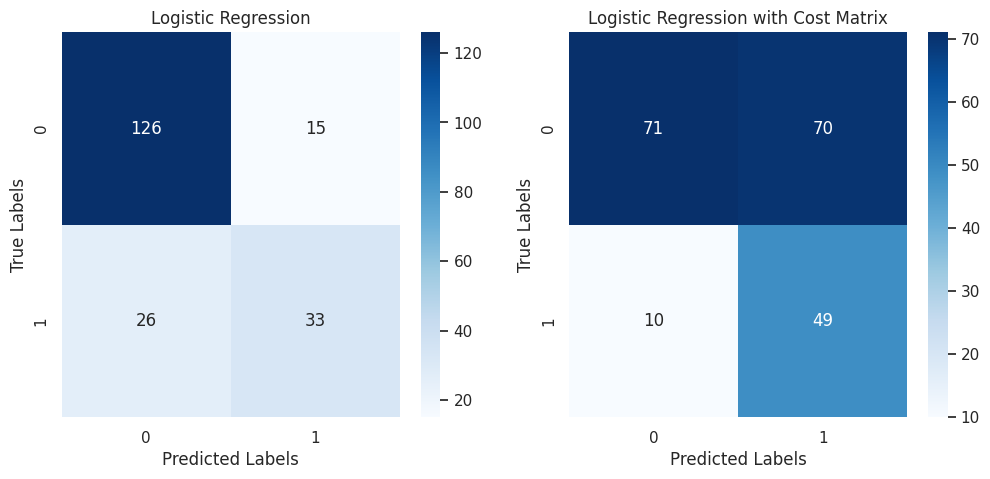

In [27]:
# Confusion matrix for Logistic Regression without cost matrix
model_lr = models["Logistic Regression"]
y_pred_lr = model_lr.predict(X_test_processed)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
#print(f'Confusion Matrix for Logistic Regression:\n{conf_matrix_lr}')

# Confusion matrix for Logistic Regression with cost matrix
model_lr_cm = models["Logistic Regression CM"]
y_pred_lr_cm = model_lr_cm.predict(X_test_processed)
conf_matrix_lr_cm = confusion_matrix(y_test, y_pred_lr_cm)
#print(f'Confusion Matrix for Logistic Regression with Cost Matrix:\n{conf_matrix_lr_cm}')

# Plotting confusion matrices for better visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression')
ax[0].set_xlabel('Predicted Labels')
ax[0].set_ylabel('True Labels')

sns.heatmap(conf_matrix_lr_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Logistic Regression with Cost Matrix')
ax[1].set_xlabel('Predicted Labels')
ax[1].set_ylabel('True Labels')

plt.show()

In [28]:
# Compute costs for both models
cost_lr = compute_cost(conf_matrix_lr, cost_matrix)
cost_lr_cm = compute_cost(conf_matrix_lr_cm, cost_matrix)

print(f'Total Cost for Logistic Regression: {cost_lr}')
print(f'Total Cost for Logistic Regression with Cost Matrix: {cost_lr_cm}')

Total Cost for Logistic Regression: 145
Total Cost for Logistic Regression with Cost Matrix: 120


## ROC Curve and AUC Plotting
- ROC (Receiver Operating Characteristic) Curve:
 
The ROC curve plots the true positive rate against the false positive rate, illustrating a binary classifier's performance across different classification thresholds.

- AUC (Area Under the Curve):

AUC quantifies a binary classification model's overall ability to distinguish between positive and negative instances, with higher values indicating better discrimination ability.



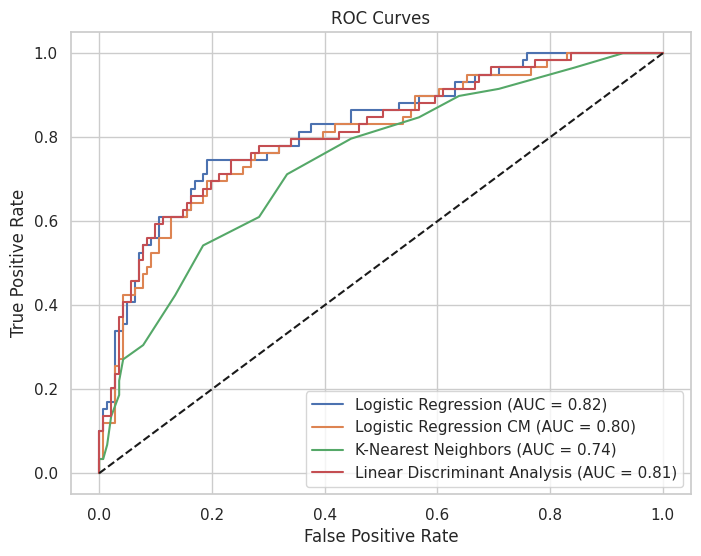

Model ROC AUC:


{'Logistic Regression': 0.8186080057699242,
 'Logistic Regression CM': 0.8023800937612693,
 'K-Nearest Neighbors': 0.7425171294626759,
 'Linear Discriminant Analysis': 0.8106743598990264}

In [29]:
# Calculate ROC curve and AUC

roc_results = {}
plt.figure(figsize=(8, 6))
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    #positive_label = 'Good Risk'  # Correct positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob) #, pos_label=positive_label) 
    auc_value = roc_auc_score(y_test, y_prob)
    roc_results[name] = auc_value
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.2f})")

# Add plot details
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

print("Model ROC AUC:")
roc_results

# Feature Importance Analysis

We use the logistic regression model with cost matrix, fitted with one feature at a time (considering the 61 features), and we compare the results.

In this way we find the importance of each single feature considered individually.

In [30]:
X = german_data.drop(columns=['Target'])
y = german_data['Target'] 
X_train_processed, X_test_processed, y_train, y_test, all_feature_names = preprocess_data(X, y, numerical_features, categorical_features)

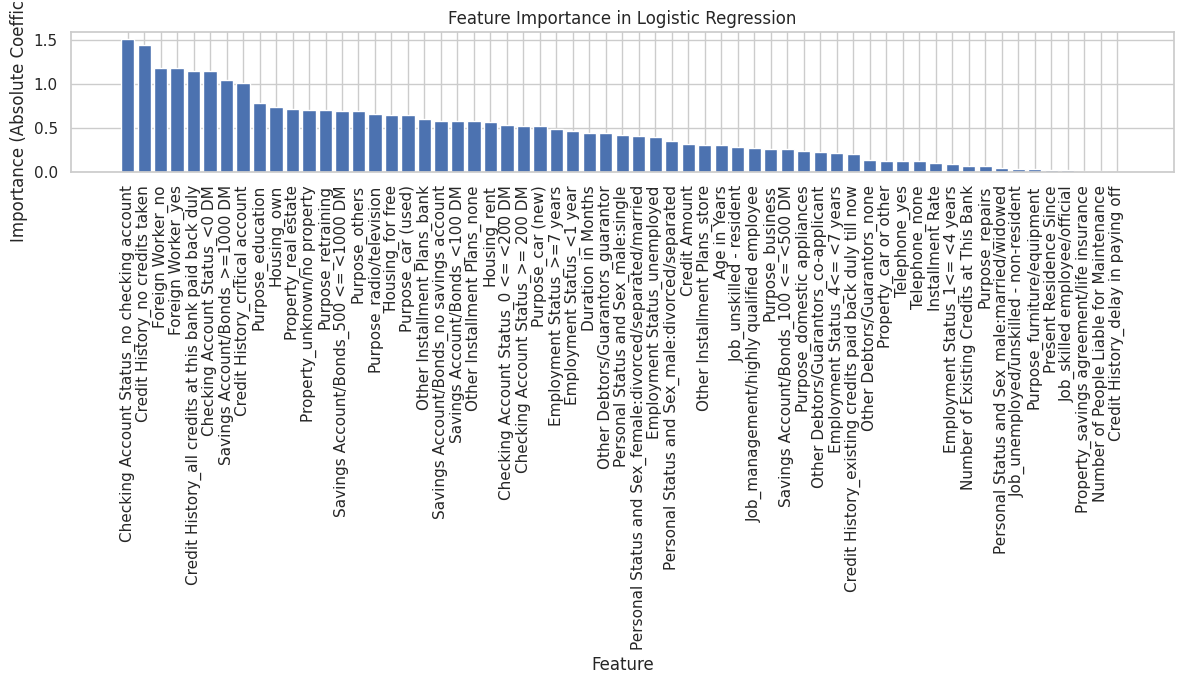

In [31]:
# Compute feature importances
feature_importance = {}

for feature in range(X_train_processed.shape[1]):
    # Select only the specific feature
    X_train_single = X_train_processed[:, [feature]]
    X_test_single = X_test_processed[:, [feature]]

    # Fit Logistic Regression
    modelone = LogisticRegression(max_iter=1000, class_weight=class_weights)
    modelone.fit(X_train_single, y_train)

    # Store the absolute value of the coefficient
    feature_importance[all_feature_names[feature]] = abs(modelone.coef_[0][0])

# Sort features by their importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# Plot the feature importances
plt.figure(figsize=(12, 7))
plt.bar([f[0] for f in sorted_features], [f[1] for f in sorted_features])
plt.xlabel("Feature")
plt.ylabel("Importance (Absolute Coefficient)")
plt.title("Feature Importance in Logistic Regression")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Subset Analysis

Analyze the performance of the same models as before, using the subset of the top 5 most important features identified in the feature importance analysis.

In [32]:
X = german_data.drop(columns=['Target'])
y = german_data['Target'] 
X_train_processed, X_test_processed, y_train, y_test, all_feature_names = preprocess_data(X, y, numerical_features, categorical_features)

In [33]:
# Define a function to select top N features
def select_top_features(X, feature_names, sorted_features, top_n):
    top_feature_names = [f[0] for f in sorted_features[:top_n]]
    top_feature_indices = [feature_names.index(name) for name in top_feature_names]
    return X[:, top_feature_indices]

Cost with top 5 features: 93
Cost with top 10 features: 110
Cost with top 15 features: 107
Cost with top 20 features: 90


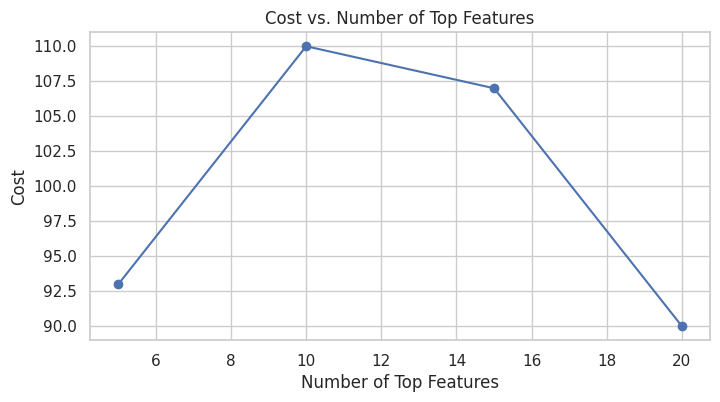

In [34]:
# Evaluate models with different numbers of top features
results = {}
for top_n in [5, 10, 15, 20]: 
    X_train_top = select_top_features(X_train_processed, all_feature_names, sorted_features, top_n)
    X_test_top = select_top_features(X_test_processed, all_feature_names, sorted_features, top_n)
    
    model_top = LogisticRegression(max_iter=1000, class_weight=class_weights)
    model_top.fit(X_train_top, y_train)
    y_pred_top = model_top.predict(X_test_top)
    
    # Compute confusion matrix and cost
    conf_matrix = confusion_matrix(y_test, y_pred_top)
    cost = compute_cost(conf_matrix, cost_matrix)
    results[top_n] = cost
    print(f"Cost with top {top_n} features: {cost}")

# Plot the results to visualize the performance
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Number of Top Features")
plt.ylabel("Cost")
plt.title("Cost vs. Number of Top Features")
plt.grid(True)
plt.show()

Cost with top 5 features: 93


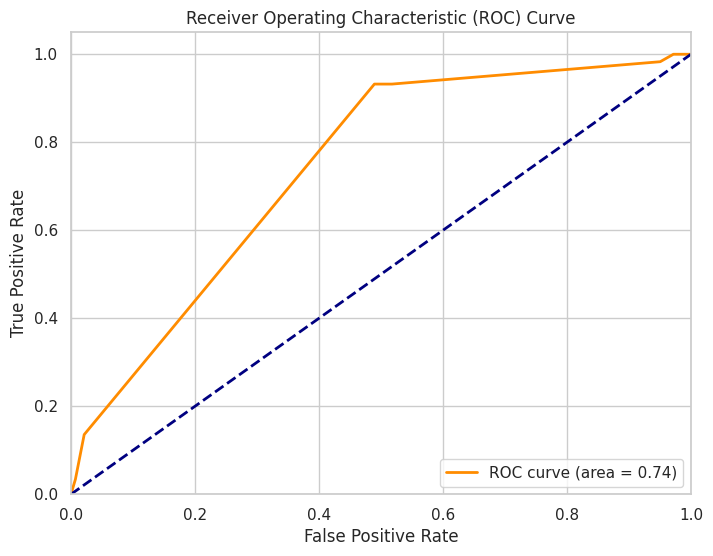

In [35]:
top_n = 5

X_train_top = select_top_features(X_train_processed, all_feature_names, sorted_features, top_n)
X_test_top = select_top_features(X_test_processed, all_feature_names, sorted_features, top_n)

# Train and evaluate the model with the top features
model_top = LogisticRegression(max_iter=1000, class_weight=class_weights)
model_top.fit(X_train_top, y_train)
y_pred_top = model_top.predict(X_test_top)

# Compute confusion matrix and cost
conf_matrix = confusion_matrix(y_test, y_pred_top)
cost = compute_cost(conf_matrix, cost_matrix)
print(f"Cost with top {top_n} features: {cost}")

# Predict probabilities for ROC and AUC
y_pred_proba = model_top.predict_proba(X_test_top)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Backward Elimination for Feature Selection with Logistic Regression


In [36]:
X = german_data.drop(columns=['Target'])
y = german_data['Target'] 
X_train_processed, X_test_processed, y_train, y_test, all_feature_names = preprocess_data(X, y, numerical_features, categorical_features)

In [37]:
logreg_be = LogisticRegression(max_iter=1000, class_weight=class_weights)

# Define the initial set of features
features = np.arange(X_train_processed.shape[1])

# Track the best subset of features and its associated cost
best_cost_be = float('inf')
best_features_be = features

# Start backward elimination
while len(features) > 0:
    # Train the model using the current subset of features
    logreg_be.fit(X_train_processed[:, features], y_train)
    
    # Make predictions on the training set
    y_train_pred = logreg_be.predict(X_train_processed[:, features])
    
    # Compute the confusion matrix
    conf_matrix = confusion_matrix(y_train, y_train_pred)
    
    # Compute the total cost based on the confusion matrix
    total_cost = compute_cost(conf_matrix, cost_matrix)
    
    # If the current subset of features reduces the total cost, update the best features and cost
    if total_cost < best_cost_be:
        best_cost_be = total_cost
        best_features_be = features.copy()
    else:
        # If removing features doesn't reduce the cost, break the loop
        break
    
    # Remove the least significant feature
    least_significant_feature_be = np.argmin(np.abs(logreg_be.coef_).flatten())
    features = np.delete(features, least_significant_feature_be)

# Train the final model using the best subset of features
logreg_be.fit(X_train_processed[:, best_features_be], y_train)

# Evaluate the model on the test set
y_test_pred = logreg_be.predict(X_test_processed[:, best_features_be])
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
test_total_cost = compute_cost(conf_matrix_test, cost_matrix)

print("Optimal number of features:", len(best_features_be))
print("Total misclassification cost on the test set:", test_total_cost)
print("Confusion matrix on the test set:\n", conf_matrix_test)

Optimal number of features: 61
Total misclassification cost on the test set: 120
Confusion matrix on the test set:
 [[71 70]
 [10 49]]


In [38]:
# Get the coefficients and feature names for the best features
coefficients = logreg_be.coef_[0]
best_feature_names = [all_feature_names[i] for i in best_features_be]

# Combine feature names and coefficients into a DataFrame for better readability
coef_df = pd.DataFrame({'Feature': best_feature_names, 'Coefficient': coefficients})

# Sort by the absolute value of the coefficient
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute Coefficient', ascending=False)

coef_df.drop(columns=['Absolute Coefficient'])

,Feature,Coefficient
18,Purpose_car (used),-1.139346
20,Purpose_education,1.117611
10,Checking Account Status_no checking account,-0.953449
25,Purpose_retraining,-0.945861
55,Job_unemployed/unskilled - non-resident,-0.895477
...,...,...
49,Other Installment Plans_store,0.044254
43,Property_car or other,0.028723
36,Personal Status and Sex_female:divorced/separa...,0.011559
4,Present Residence Since,-0.009355


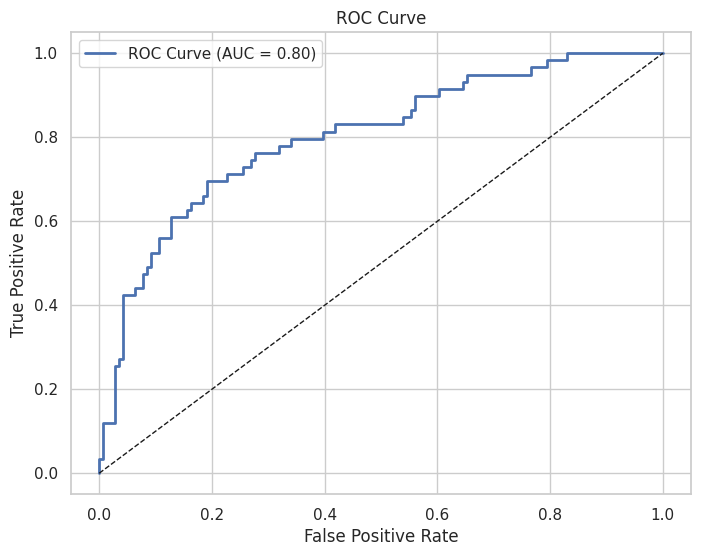

AUC: 0.8023800937612693


In [39]:
# Plot ROC curve and calculate AUC
y_pred_prob = logreg_be.predict_proba(X_test_processed[:, best_features_be])[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Diagonal line for reference (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

print("AUC:", auc)